In [3]:
%load_ext autoreload
%autoreload 2


In [4]:
from systematic_plots import * 
import gemmi

def points_in_mask(points, mask):
    """
    Given a list of points in 3D coordinates between 0 and 1,
    and a binary 3D mask, return all points that are within the mask.

    Parameters:
        points (np.ndarray): shape (N, 3), coordinates between 0 and 1
        mask (np.ndarray): shape (X, Y, Z), binary mask

    Returns:
        np.ndarray: points within the mask
    """
    points = np.asarray(points)
    shape = mask.shape
    # Convert normalized coordinates to integer indices
    indices = np.floor(points * np.array(shape)).astype(int)
    # Clip indices to valid range
    indices = np.clip(indices, 0, np.array(shape) - 1)
    # Check mask value at each index
    mask_values = mask[indices[:,0], indices[:,1], indices[:,2]]
    return points[mask_values > 0]

def get_atom_locations_from_pdb(pdb_file):
    """
    Parses a PDB file and returns a dictionary mapping atom IDs to their 3D coordinates.

    Parameters:
        pdb_file (str): Path to the PDB file.

    Returns:
        dict: {atom_id: np.array([x, y, z])}
    """
    atom_locations = {}
    with open(pdb_file, 'r') as f:
        for line in f:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                atom_id = int(line[6:11].strip())
                x = float(line[30:38].strip())
                y = float(line[38:46].strip())
                z = float(line[46:54].strip())
                atom_locations[atom_id] = np.array([x, y, z])

    return atom_locations
def get_atom_locations_from_pdb_fractional(pdb_file):
        """
        Parses a PDB file and returns a dictionary mapping atom IDs to their fractional 3D coordinates using gemmi.

        Parameters:
            pdb_file (str): Path to the PDB file.

        Returns:
            dict: {atom_id: np.array([frac_x, frac_y, frac_z])}
        """
        structure = gemmi.read_structure(pdb_file)
        # Use the first model and first unit cell
        cell = structure.cell
        print(cell)
        grid = gemmi.FloatGrid(10, 10, 10)
        grid.set_unit_cell(cell)
        atom_locations = {}
        for model in structure:
            for chain in model:
                for residue in chain:
                    for atom in residue:
                        atom_id = atom.serial
                        frac = grid.get_fractional(atom.pos.x, atom.pos.y, atom.pos.z)
                        atom_locations[atom_id] = np.array([frac.x, frac.y, frac.z])
        return atom_locations

pdb_file = "/Users/sbielfel/Nextcloud2/time_resolved/data/MAXIV_ECH_new/models/ECH_MAXIV_dark_model.pdb"


get_atom_locations_from_pdb_fractional(pdb_file)

<gemmi.UnitCell(83.185, 83.185, 89.5, 90, 90, 120)>


TypeError: get_fractional(): incompatible function arguments. The following argument types are supported:
    1. (self: gemmi.GridMeta, arg0: typing.SupportsInt, arg1: typing.SupportsInt, arg2: typing.SupportsInt) -> gemmi.Fractional

Invoked with: <gemmi.FloatGrid(10, 10, 10)>, -29.512, -22.247, -5.855

In [19]:
%load_ext autoreload
%autoreload 2
from systematic_plots import load_ocp_paths, adding_maps

info_container=load_ocp_paths()[0]
info_container=load_photolyase_paths()[0]
evaluation_path = load_homepath() + "../evaluation/"

diffmaps, map_dark, map_light, info_container, evaluation_path_basis = calculate_objects(
    info_container, evaluation_path, return_light=True
)
diffmap = diffmaps["kweighted"] 

2025-08-27 14:37:30,954: systematic_plots: INFO: Loading Photolyase paths (systematic_plots.py:1159)
2025-08-27 14:37:30,954: systematic_plots: INFO: Loaded Photolyase 100us with photolyase_100us (systematic_plots.py:1204)
2025-08-27 14:37:30,955: systematic_plots: INFO: Loaded Photolyase 10us with photolyase_10us (systematic_plots.py:1204)
2025-08-27 14:37:30,956: systematic_plots: INFO: Loaded Photolyase 30ns with photolyase_30ns (systematic_plots.py:1204)
2025-08-27 14:37:30,956: systematic_plots: INFO: Loaded Photolyase 300ps with photolyase_300ps (systematic_plots.py:1204)
2025-08-27 14:37:30,956: systematic_plots: INFO: Loaded Photolyase 30us with photolyase_30us (systematic_plots.py:1204)
2025-08-27 14:37:30,956: systematic_plots: INFO: Loaded Photolyase 3ps with photolyase_3ps (systematic_plots.py:1204)
2025-08-27 14:37:30,957: systematic_plots: INFO: Loaded Photolyase 1ns with photolyase_1ns (systematic_plots.py:1204)
2025-08-27 14:37:30,957: systematic_plots: INFO: Loaded Pho

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2025-08-27 14:37:32,359: systematic_plots: INFO: Reading from /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../evaluation/photolyase_100us/diffmaps24.mtz (systematic_plots.py:1685)


In [20]:
info_container["pdbloc_dark"] 

'/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../photolyase_share_reviewers/1_superdark/superdark_deposit.pdb'

P 21 21 21
True
1
90
(-0.0023148148148148147, 0.9976851851851852, 0.9966666666666667, -0.0033333333333333335)


interactive(children=(IntSlider(value=0, description='f0', max=89), Output()), _dom_classes=('widget-interact'…

2025-08-27 14:38:39,934: meteorize: WARNING: Used threshold for posmask: 0.324, found 2115 blobs (meteorize.py:580)


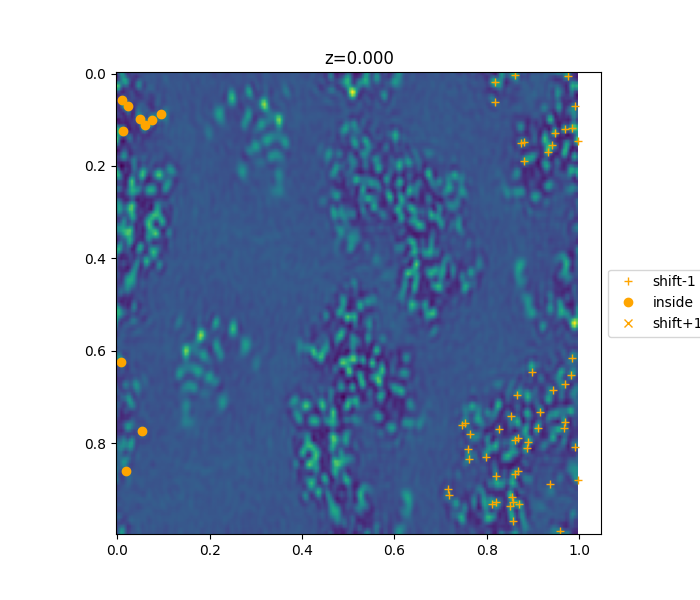

90
(-0.0023148148148148147, 0.9976851851851852, 0.9965277777777778, -0.003472222222222222)


interactive(children=(IntSlider(value=0, description='f0', max=89), Output()), _dom_classes=('widget-interact'…

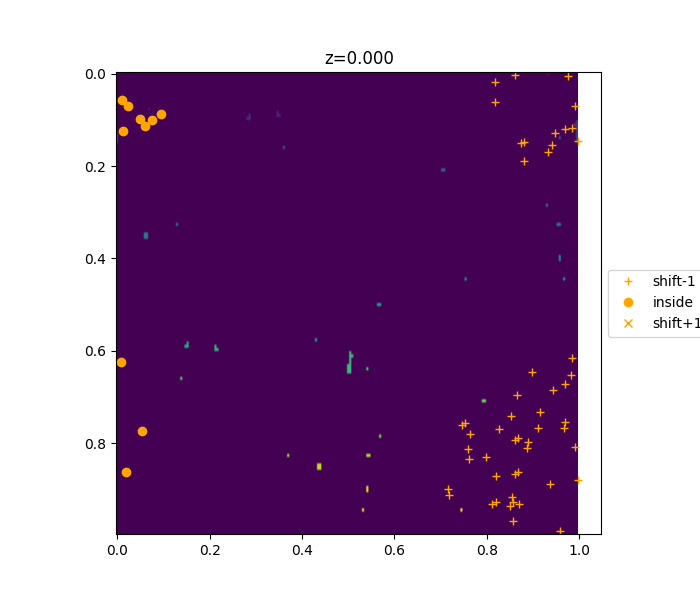

In [23]:
# from plotting3d import mtz_comp, get_pos_from_pdb
from output_eval import mtz_comp

search_occs=list([[0.445],[0.575]])
struc_dark = gemmi.read_structure(info_container["pdbloc_dark"])

map_dark_comp = meteor.sfcalc.gemmi_structure_to_calculated_map(
    struc_dark, high_resolution_limit=1.8, #low_resolution_limit=10
)
def get_pdb_pos(pdbname):
    st = gemmi.read_structure(pdbname)
    st.remove_alternative_conformations()
    st.remove_hydrogens()
    st.remove_waters()
    # st.remove_ligands_and_waters()
    st.remove_empty_chains()
    pos_list = np.array([st.cell.fractionalize(rca.atom.pos).tolist()   for rca in st[0].all()])
    print((st.spacegroup_hm))
    print((st.cell.is_compatible_with_spacegroup(gemmi.SpaceGroup("P 1"))))
    st.setup_cell_images()
    # print(st.find_nearest
    st.setup_cell_images()
    pos_list = np.array([st.cell.fractionalize(rca.atom.pos).tolist()   for rca in st[0].all()])
    print(len(st))
    return pos_list

# search_occs= list([[0.115],[0.775]])
diffmap_np = diffmap.to_3d_numpy_map(map_sampling=3)
map_dark_np = map_dark.to_3d_numpy_map(map_sampling=3)
map_comp_np = map_dark_comp.to_3d_numpy_map(map_sampling=3)
plt.close('all')
%matplotlib widget

pos2 = get_pdb_pos(info_container["pdbloc_dark"])
# _ = mtz_comp(frac_list_dark, map_comp_np)
_ = mtz_comp(pos2, map_dark_np/np.std(map_dark_np), )
# _ = mtz_comp(frac_list_dark, map_dark_np)
from meteorize import calculate_all_pos_blobs, filter_pos_blobs_rmsd
all_neg_blobs = calculate_all_pos_blobs(
        -diffmap_np,
        sigma = 3
        )
plt.show()
_ = mtz_comp(pos2, all_neg_blobs, )

plt.show()


128
(-0.0030864197530864196, 0.9969135802469136, 0.99609375, -0.00390625)


interactive(children=(IntSlider(value=0, description='f0', max=127), Output()), _dom_classes=('widget-interact…

0

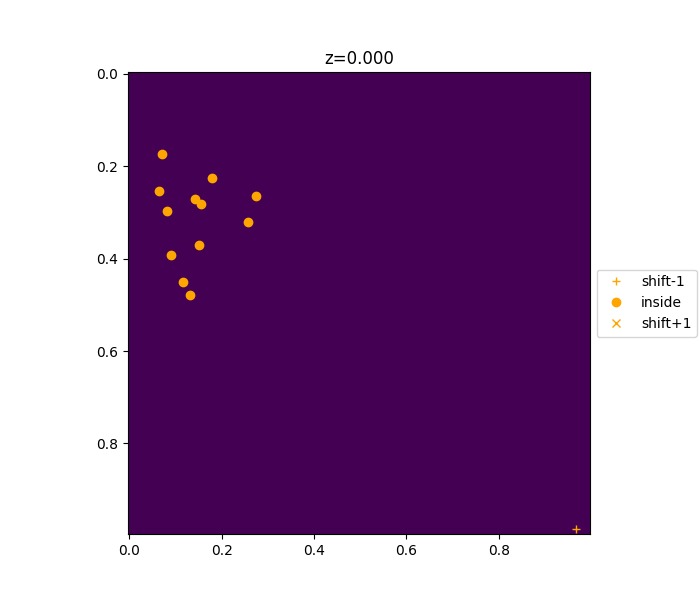

In [ ]:

neg_blobs, neg_blobs_masks = filter_pos_blobs_rmsd(
            -diffmap_np,
            all_neg_blobs.copy(),
            threshold=10,
            maximum_quantity=1500,
        )
_ = mtz_comp(pos2, neg_blobs>0)
np.sum(neg_blobs>0)


In [104]:

diffmap_np.min()/diffmap_np.std()

-26.785337

In [ ]:
mtz_comp(
    mtzdata= diffmap.to_3d_numpy_map(map_sampling=3), 
         pos_list=info_container["pos_list"])

KeyError: 'pos_list'

In [ ]:
diffmap : rsmap.Map = diffmaps["tv"]